<span style='font-size:x-large'>**Energy Insecurity Capstone Project**</span>

Author: Hilary Griggs 

Date: 2025\-2026

<span style='font-size:large'>Environmental Research Question: </span>

How has household energy insecurity changed over time in the United States, and how does it differ across income groups?

Link to GitHub repository: [https://github.com/hilarybg/energy\-insecurity](https://github.com/hilarybg/energy-insecurity) 


In [6]:
import pandas as pd

#load data
df_2024 = pd.read_excel("../data/raw/eia_recs_2024.xlsx")

df_2024.head()

,Preliminary data release date: March 2026,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"Table HC11.1 Household energy insecurity, 2024",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Number of housing units (million),NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Households reporting...,NaN,NaN,NaN,NaN,NaN
3,NaN,Total U.S.a,Any household energy insecurityb,Reducing or forgoing food or medicine to pay e...,Leaving home at unhealthy temperature,Receiving disconnect or delivery stop notice,Unable to use heating equipmentc,Unable to use air-conditioning equipmentd
4,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16


In [7]:
#inspect columns and rows 
df_2024.columns
df_2024.head(10)

,Preliminary data release date: March 2026,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"Table HC11.1 Household energy insecurity, 2024",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Number of housing units (million),NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Households reporting...,NaN,NaN,NaN,NaN,NaN
3,NaN,Total U.S.a,Any household energy insecurityb,Reducing or forgoing food or medicine to pay e...,Leaving home at unhealthy temperature,Receiving disconnect or delivery stop notice,Unable to use heating equipmentc,Unable to use air-conditioning equipmentd
4,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
5,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
7,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
8,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83
9,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52


In [8]:
#fix which row is functioning as header 
df_2024 = pd.read_excel("../data/raw/eia_recs_2024.xlsx", header=3)

# Drop empty rows
df_2024 = df_2024[df_2024.iloc[:,0].notna()]

# Rename first column
df_2024 = df_2024.rename(columns={df_2024.columns[0]: "Region"})

df_2024.head()


,Region,Unnamed: 1,Households reporting...,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83


In [9]:
#look at column names
list(df_2024.columns)


['Region',
 'Unnamed: 1',
 'Households reporting...',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7']

In [10]:
#inspect real header rows
df_2024.head(8)

,Region,Unnamed: 1,Households reporting...,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83
6,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52
7,East North Central,19.47,5.97,4.43,2.15,2.32,0.88,0.95
8,West North Central,9.02,2.55,1.85,1.01,1.05,0.47,0.57


In [11]:
#rename columns
df_2024.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]

df_2024.head()

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16
2,Census region and division,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83


In [12]:
# Remove blank and section-header rows
df_2024 = df_2024[df_2024["region"].notna()]
df_2024 = df_2024[df_2024["region"] != "Census region and division"]

# Add year 
df_2024["year"] = 2024

# Preview 
df_2024.head(10)

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac,year
1,All homes,132.54,43.56,32.89,17.55,16.19,6.83,8.16,2024
3,Northeast,22.93,6.87,5.12,3.12,2.39,0.94,1.16,2024
4,New England,6.2,1.84,1.39,0.86,0.68,0.3,0.34,2024
5,Middle Atlantic,16.73,5.04,3.73,2.26,1.71,0.63,0.83,2024
6,Midwest,28.49,8.52,6.28,3.15,3.37,1.35,1.52,2024
7,East North Central,19.47,5.97,4.43,2.15,2.32,0.88,0.95,2024
8,West North Central,9.02,2.55,1.85,1.01,1.05,0.47,0.57,2024
9,South,51.49,18.25,14.11,6.73,7.39,3.23,3.81,2024
10,South Atlantic,27.38,8.76,6.67,3.27,3.31,1.41,1.69,2024
11,East South Central,8.01,3.11,2.34,1.31,1.19,0.78,0.79,2024


In [13]:
#check data types 
df_2024.info()


<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 1 to 96
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   region                     94 non-null     object
 1   total_households_million   79 non-null     object
 2   any_insecurity             79 non-null     object
 3   food_or_medicine_tradeoff  79 non-null     object
 4   unsafe_temperature         79 non-null     object
 5   disconnect_notice          79 non-null     object
 6   no_heating                 79 non-null     object
 7   no_ac                      79 non-null     object
 8   year                       94 non-null     int64 
dtypes: int64(1), object(8)
memory usage: 7.3+ KB


In [14]:
# Convert the numeric columns that are showing as objects 
num_cols = [
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]

for col in num_cols:
    df_2024[col] = pd.to_numeric(df_2024[col], errors="coerce")

df_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 1 to 96
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   region                     94 non-null     object 
 1   total_households_million   79 non-null     float64
 2   any_insecurity             78 non-null     float64
 3   food_or_medicine_tradeoff  78 non-null     float64
 4   unsafe_temperature         78 non-null     float64
 5   disconnect_notice          78 non-null     float64
 6   no_heating                 76 non-null     float64
 7   no_ac                      76 non-null     float64
 8   year                       94 non-null     int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 7.3+ KB


In [15]:
# Repeat this process for 2020 data 
df_2020 = pd.read_excel("../data/raw/eia_recs_2020.xlsx", header=3)
df_2020.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]
df_2020 = df_2020[df_2020["region"].notna()]
df_2020 = df_2020[df_2020["region"] != "Census region and division"]
df_2020["year"] = 2020

for col in num_cols:
    df_2020[col] = pd.to_numeric(df_2020[col], errors="coerce")

In [16]:
#Repeat this process for 2015 data 
df_2015 = pd.read_excel("../data/raw/eia_recs_2015.xlsx", header=3)
df_2015.columns = [
    "region",
    "total_households_million",
    "any_insecurity",
    "food_or_medicine_tradeoff",
    "unsafe_temperature",
    "disconnect_notice",
    "no_heating",
    "no_ac"
]
df_2015 = df_2015[df_2015["region"].notna()]
df_2015 = df_2015[df_2015["region"] != "Census region and division"]
df_2015["year"] = 2015

for col in num_cols:
    df_2015[col] = pd.to_numeric(df_2015[col], errors="coerce")

In [17]:
# Combine the three years 
df_all = pd.concat([df_2015, df_2020, df_2024], ignore_index=True)
df_all.head()

,region,total_households_million,any_insecurity,food_or_medicine_tradeoff,unsafe_temperature,disconnect_notice,no_heating,no_ac,year
0,All homes,118.2,37.0,25.3,12.8,17.2,6.1,6.9,2015
1,Northeast,21.0,6.2,4.0,2.5,2.7,1.4,0.6,2015
2,New England,5.6,2.0,1.2,0.8,0.9,0.4,0.4,2015
3,Middle Atlantic,15.4,4.1,2.8,1.7,1.8,1.0,0.2,2015
4,Midwest,26.4,7.4,5.0,2.2,3.8,1.1,1.1,2015


In [20]:
# Fix the "region" column name to account for the variety within that column 

df_all = df_all.rename(columns={"region": "category"})

def classify_category(x):
    # Regions
    if x in ["Northeast", "Midwest", "South", "West"]:
        return "region"
    
    # Income groups
    elif x in [
        "Less than $10,000",
        "$10,000 to $14,999",
        "$15,000 to $29,999",
        "$30,000 to $59,999",
        "$60,000 to $99,999",
        "$100,000 to $199,999",
        "$200,000 or more"
    ]:
        return "income"
    
    # Climate regions (edit based on your data)
    elif x in [
        "Very cold/Cold",
        "Mixed-humid",
        "Mixed-dry/Hot-dry"
        "Hot-humid",
        "Marine"
    ]:
        return "climate"
    
    # Overall
    elif x == "All homes":
        return "overall"
    
    # Everything else
    else:
        return "other"

In [22]:
# Confirm and check the subsets of the first column 

df_all["category_type"] = df_all["category"].apply(classify_category)

df_all["category_type"].value_counts()

category_type
other      303
region      12
climate      8
income       8
overall      3
Name: count, dtype: int64

In [32]:
# Save cleaned dataset
df_all.to_csv("../data/processed/energy_insecurity_cleaned.csv", index=False)

<span style='font-size:x-large'>Visualizations </span>

<span style='font-size:small'>This section creates a series of visualizations representing the data. </span>


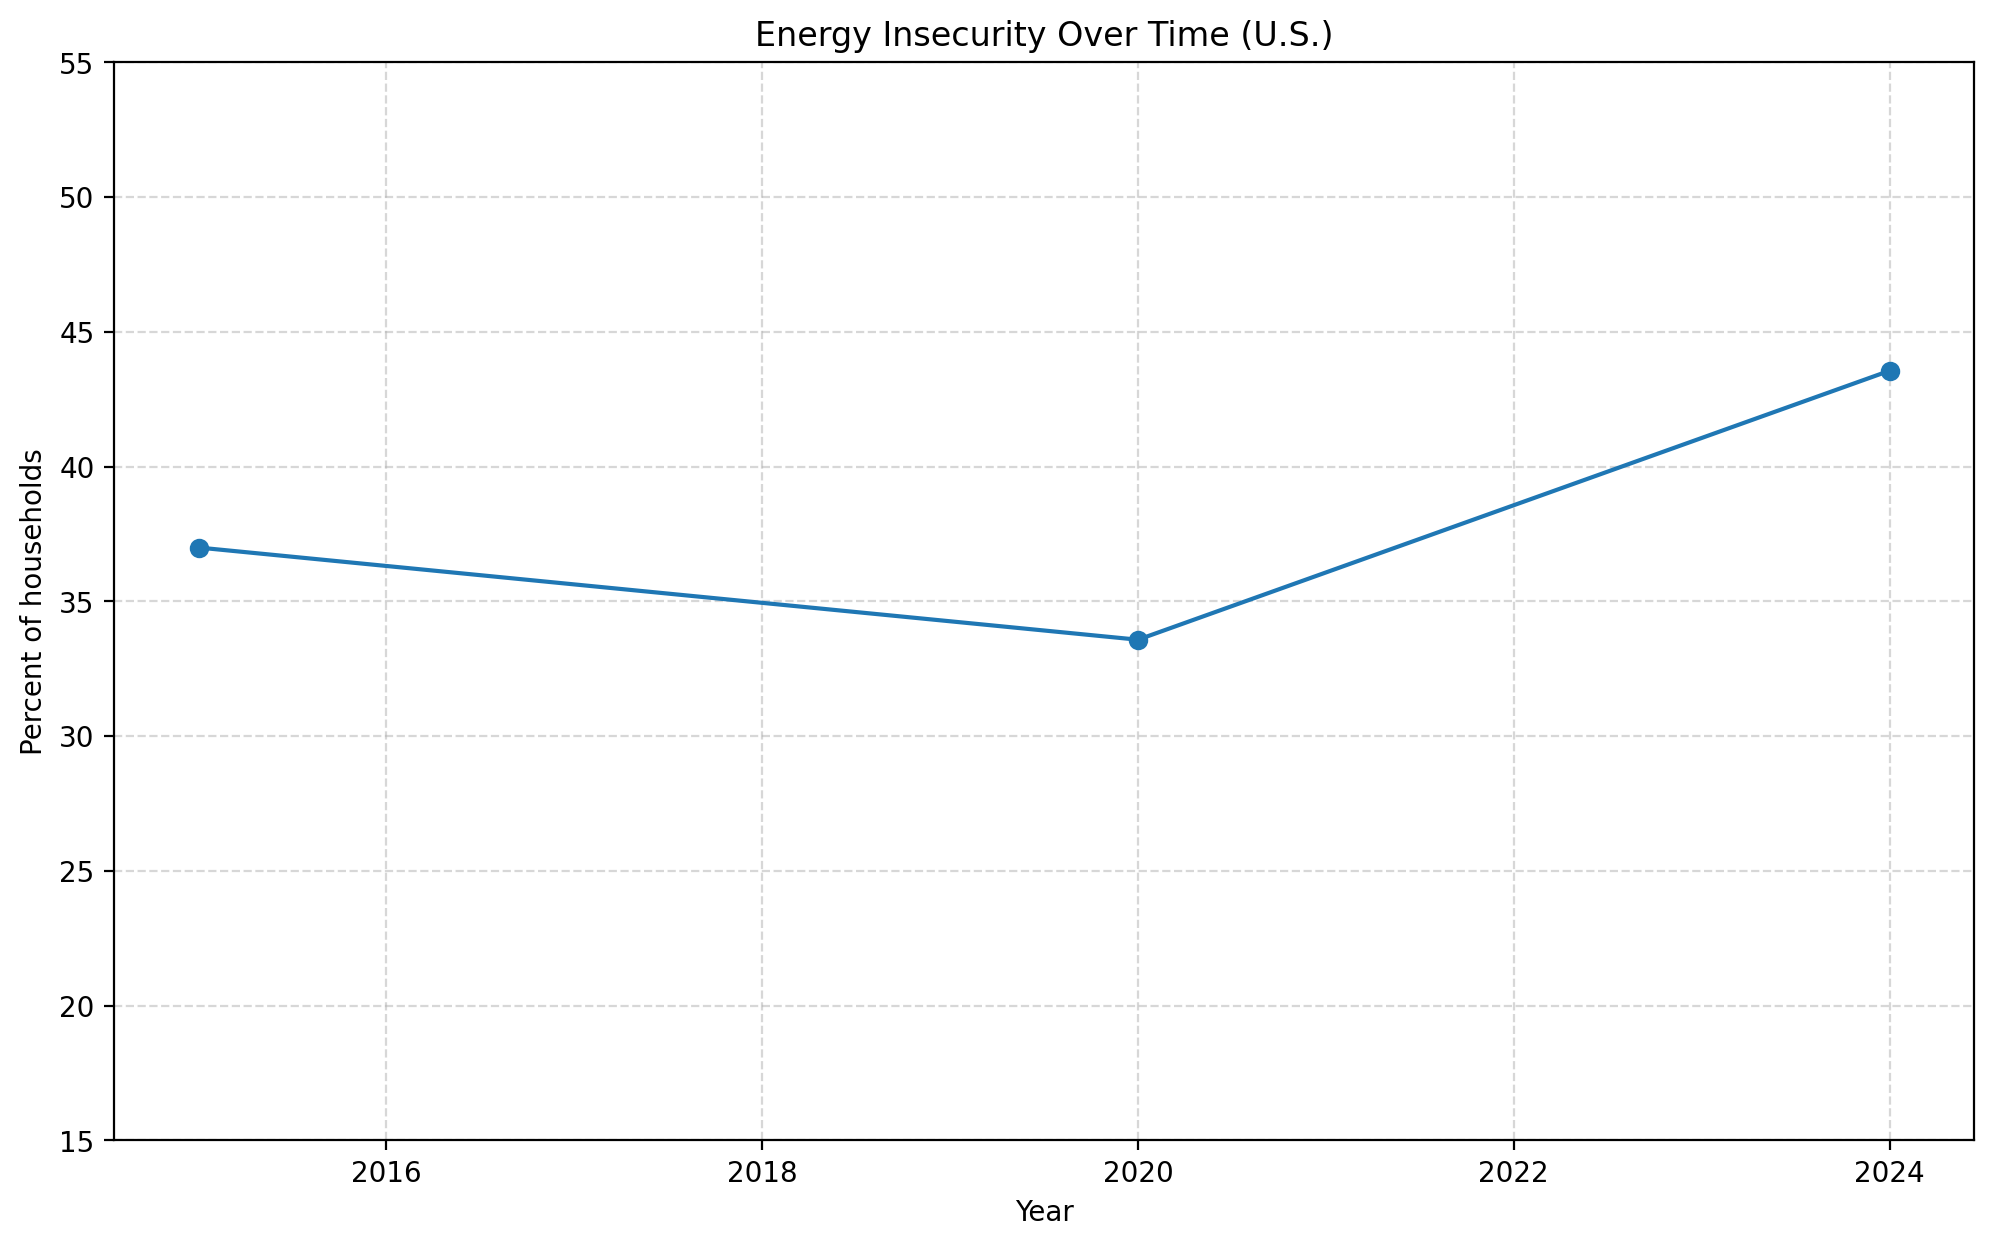

In [31]:
# Inspect national trends 

import matplotlib.pyplot as plt

df_us = df_all[df_all["category"] == "All homes"]

plt.plot(df_us["year"], df_us["any_insecurity"], marker="o")

plt.title("Energy Insecurity Over Time (U.S.)")
plt.xlabel("Year")
plt.ylabel("Percent of households")

plt.ylim(15, 55)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("../communication/figures/trend.png", bbox_inches="tight")
plt.show()


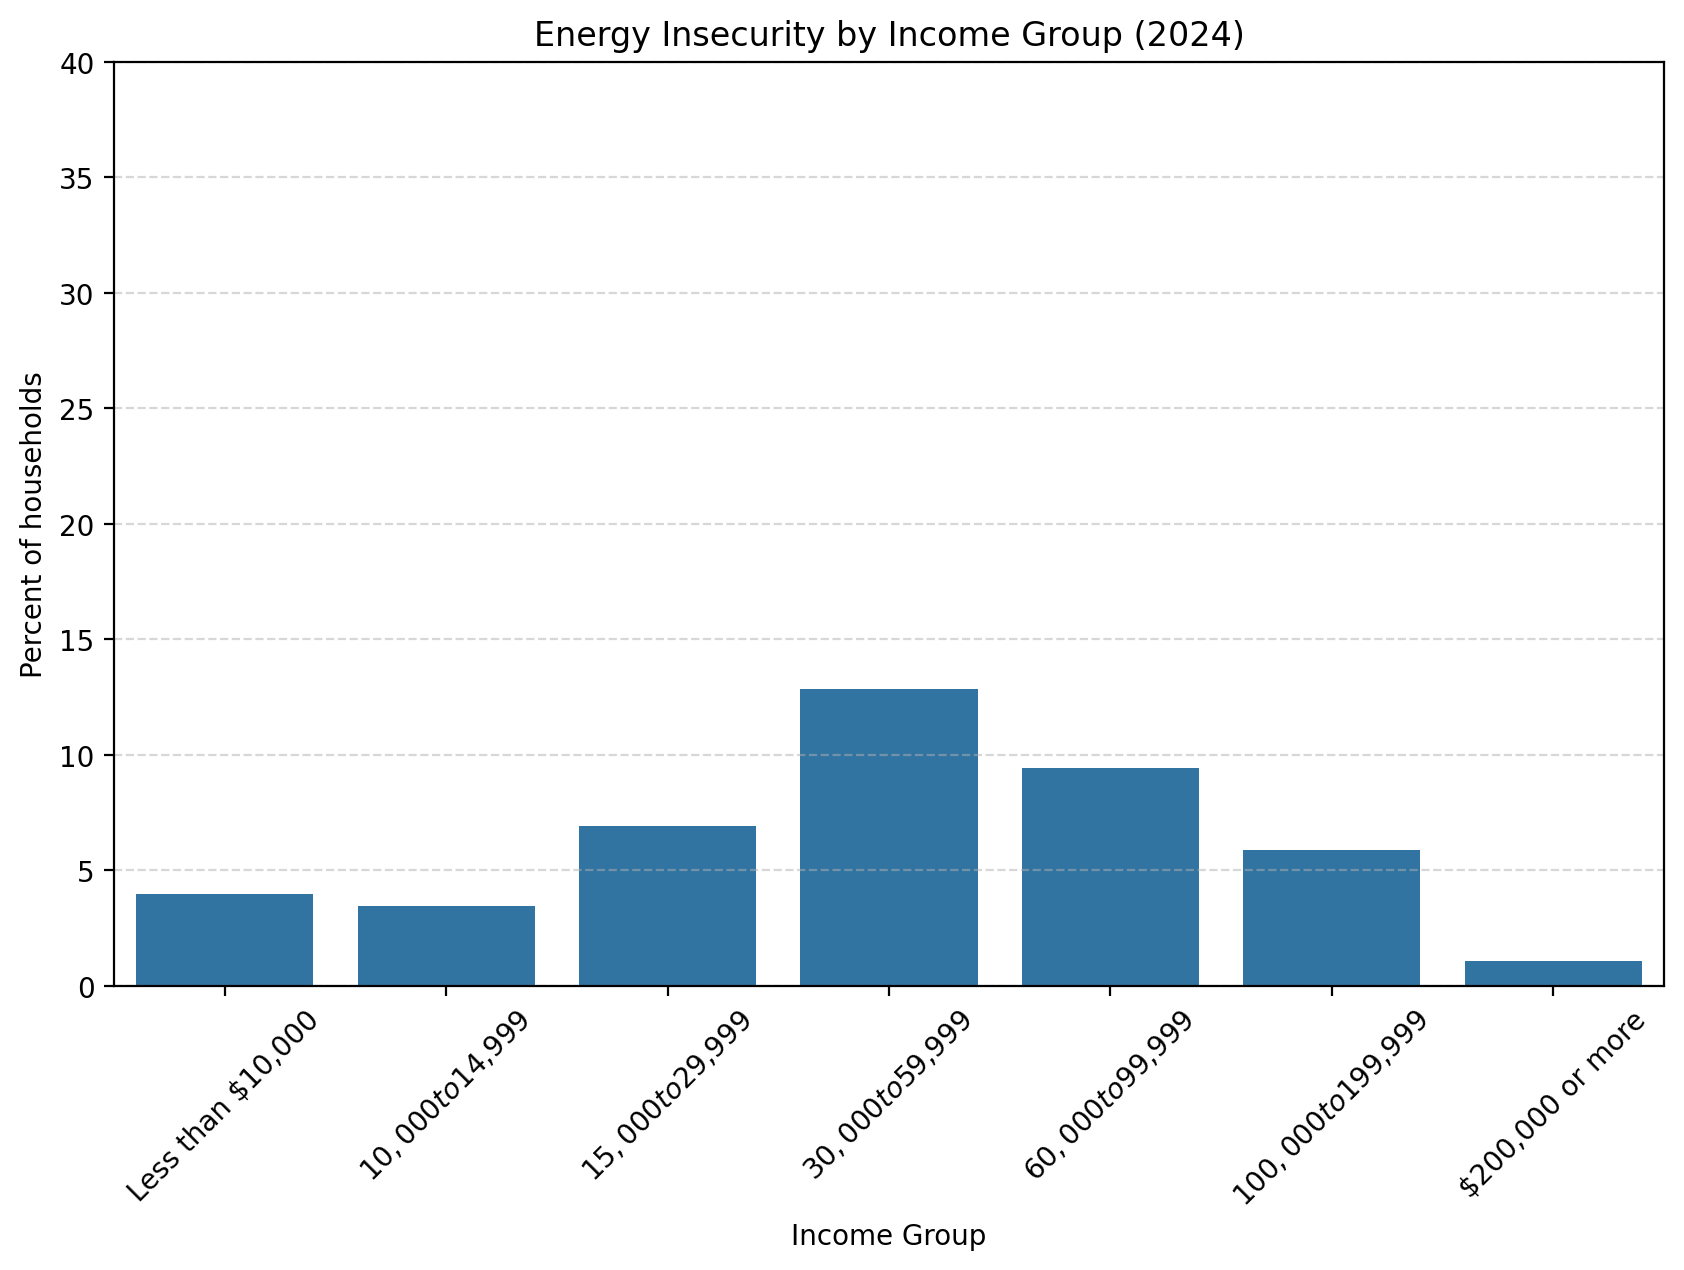

In [33]:
# Compare energy insecurity across income groups in 2024 
# The income grouping is different for all three samplings of this survey, and so I avoid forcing the data into a comparison

import seaborn as sns
import matplotlib.pyplot as plt

df_income_2024 = df_all[
    (df_all["category_type"] == "income") &
    (df_all["year"] == 2024)
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_income_2024,
    x="category",
    y="any_insecurity"
)

plt.title("Energy Insecurity by Income Group (2024)")
plt.xlabel("Income Group")
plt.ylabel("Percent of households")

plt.xticks(rotation=45)
plt.ylim(0, 40)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig("../communication/figures/income.png", bbox_inches="tight")
plt.show()

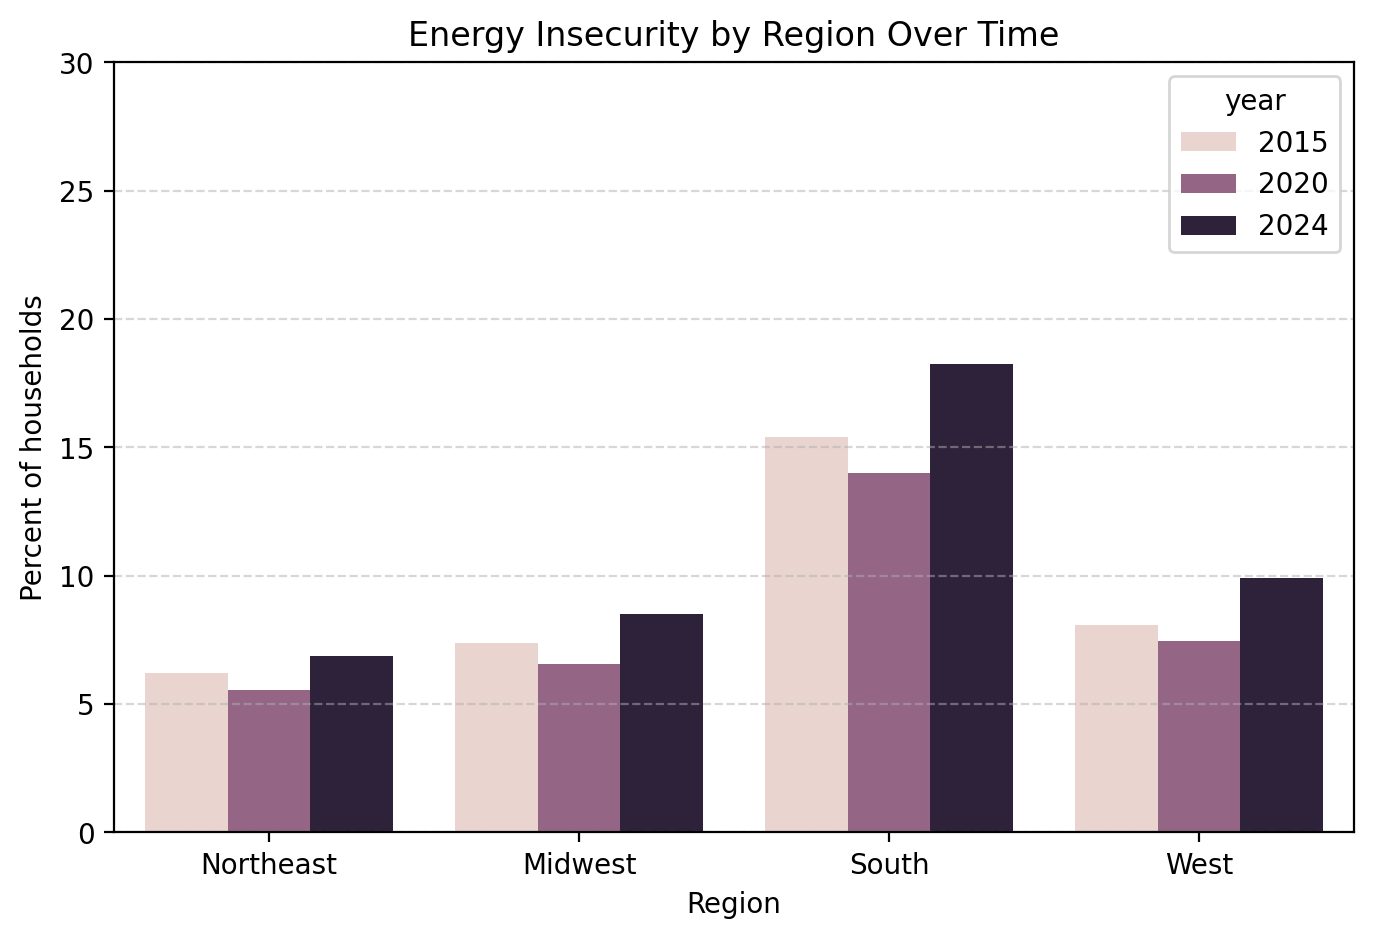

In [35]:
# Compare energy insecurity by region 
regions = ["Northeast", "Midwest", "South", "West"]

df_regions = df_all[
    (df_all["category_type"] == "region") &
    (df_all["category"].isin(regions))
] 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_regions,
    x="category",
    y="any_insecurity",
    hue="year",
    order=regions
)

plt.title("Energy Insecurity by Region Over Time")
plt.xlabel("Region")
plt.ylabel("Percent of households")

plt.ylim(0, 30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig("../communication/figures/region.png", bbox_inches="tight")
plt.show()

In [36]:
#The above chart shows significant disparities in energy insecurity by region. Find the specific values. 

regions = ["Northeast", "Midwest", "South", "West"]

df_regions = df_all[
    (df_all["category_type"] == "region") &
    (df_all["category"].isin(regions))
]

df_15_20 = df_regions[df_regions["year"].isin([2015, 2020])]

df_pivot = df_15_20.pivot(
    index="category",
    columns="year",
    values="any_insecurity"
)

df_pivot

df_pivot["change_2015_2020"] = df_pivot[2020] - df_pivot[2015]

df_pivot

year,2015,2020,change_2015_2020
category,,,
Midwest,7.4,6.58,-0.82
Northeast,6.2,5.54,-0.66
South,15.4,14.00,-1.40
West,8.1,7.46,-0.64
